# AI Technical Examination

### Project Technical Specialist IV (PhilSA - ESSMSD) 

#### Applicant : John Adrian B. Baybay
email: jbbaybay@up.edu.ph


We are to develop an end-to-end AI solution for cloud and cloud shadow masking 
from multispectral satellite imagery. The data to be used is a subset from the 
CloudSEN12+ dataset and is locally stored. 

From this dataset, which contains four classess: Clear (0), Thick Cloud (1), Thin Cloud (2), and Cloud Shadow (3), we want to develop a semantic segmentation model that classifies
every pixel into 

| Label | Class Name | Description |
|---|---|---|
| 0 | Clear | Clear |
| 1 | Cloud | Cloud |
| 2 | Cloud Shadow | Cloud Shadow  |

Thus a remapping must be done: Clear (0), Thick and Thin Cloud (1), Cloud Shadow (2). 


The machine that will be used is a macbook pro with an M2 chip. The dataset is downloaded locally. A local Jupyter notebook will be used.

## Preamble

In [1]:
import os # handles file system operations
import random # for generating random values 
import glob # to look ffor .tif and .tiff files
import numpy as np # for array manipulations
import pandas as pd # creates and formats dataframes to compute, structure, and export evaluation metrics
import matplotlib.pyplot as plt # for visualization
import rasterio # reads multi-band GeoTIFF files
import torch # to load PyTorch
import torch.nn as nn
import torch.nn.functional as F
import time 
import segmentation_models_pytorch as smp
import torch.optim.lr_scheduler as lr_scheduler

from torch.utils.data import Dataset, DataLoader
from matplotlib.colors import ListedColormap
from tqdm import tqdm # for progress bars
#--------------------------------------------------#

# Set random seed for reproducibility
def rand_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) #sets the hashing algorithm
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): 
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

rand_seed(42) # the answer to life, the universe, and everything. 

# to detect hardware available for PyTorch
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple Silicon GPU (MPS) enabled.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device: NVIDIA CUDA GPU enabled.")
else:
    device = torch.device("cpu")
    print("Device: CPU enabled.")

Device: Apple Silicon GPU (MPS) enabled.


## Onboarding the Dataset and prepping 

In [2]:
class CloudData_Prep(Dataset):
    def __init__(self, folder_path=None, file_paths=None, augment=False):
        super().__init__()
        self.augment = augment
        
        # allow either a folder path OR a specific list of files
        if file_paths is not None:
            self.file_paths = file_paths
        elif folder_path is not None:
            search_path_tif = os.path.join(folder_path, "**", "*.tif")
            search_path_tiff = os.path.join(folder_path, "**", "*.tiff")
            self.file_paths = sorted(glob.glob(search_path_tif, recursive=True) + glob.glob(search_path_tiff, recursive=True))
        else:
            raise ValueError("You must provide either a folder_path or file_paths.")
            
        if len(self.file_paths) == 0:
            raise FileNotFoundError("No .tif or .tiff files found.")
    # for counting
    def __len__(self):
        return len(self.file_paths)
    # remapping 
    def remap_mask(self, mask):
        remapped = np.zeros_like(mask, dtype=np.int64)
        remapped[mask == 0] = 0
        remapped[(mask == 1) | (mask == 2)] = 1
        remapped[mask == 3] = 2
        return remapped
    # gets the items... takes GeoTIFFs into torch tensors
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        with rasterio.open(file_path) as src:
            data = src.read()  # Shape: (C, H, W)
            
            # bands 1-4: B02 (Blue), B03 (Green), B04 (Red), B08 (NIR)
            img = data[0:4, :, :].astype(np.float32)
            
            # band 5: CM1 expert ground-truth mask
            mask = data[4, :, :].astype(np.int64)

        # normalize satellite image reflectance to [0, 1]
        img_normalized = np.clip(img / 10000.0, 0.0, 1.0)
        
        # apply mandatory class remapping
        mask_remapped = self.remap_mask(mask)

        # Data Augmentation (so that the model does not see exact same image)
        if self.augment:
            # Horizontal Flip
            if random.random() > 0.5:
                img_normalized = np.flip(img_normalized, axis=2)
                mask_remapped = np.flip(mask_remapped, axis=1)
            # Vertical Flip
            if random.random() > 0.5:
                img_normalized = np.flip(img_normalized, axis=1)
                mask_remapped = np.flip(mask_remapped, axis=0)
            # Random 90-degree Rotations
            k = random.randint(0, 3)
            if k > 0:
                img_normalized = np.rot90(img_normalized, k, axes=(1, 2))
                mask_remapped = np.rot90(mask_remapped, k, axes=(0, 1))

        # Ensure contiguous memory before converting to PyTorch tensors
        img_tensor = torch.tensor(np.ascontiguousarray(img_normalized), dtype=torch.float32)
        mask_tensor = torch.tensor(np.ascontiguousarray(mask_remapped), dtype=torch.long)

        return img_tensor, mask_tensor, file_path

Semantic Segmentation Model

In [3]:
# here we define the model we will implement. We utilize a U-Net architecture

# double convolution
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# builds the U-net network 
class UNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=3): # 4-input(R,G,B,NR) --- 3-output(Clear, Cloud, Shadow)
        super().__init__()
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64)) # zoom in 1 
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128)) # zoom in 2
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256)) # zoom in 3
        # zoom out 1
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2) 
        self.conv1 = DoubleConv(256, 128)
        # zoom out 2
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        # zoom out 3
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv3 = DoubleConv(64, 32)
        
        self.outc = nn.Conv2d(32, num_classes, 1) # maps into 3 layers after refinement 

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        # Upsample 1
        x = self.up1(x4)
        diffY = x3.size()[2] - x.size()[2]
        diffX = x3.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)
        
        # Upsample 2
        x = self.up2(x)
        diffY = x2.size()[2] - x.size()[2]
        diffX = x2.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        
        # Upsample 3
        x = self.up3(x)
        diffY = x1.size()[2] - x.size()[2]
        diffX = x1.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        
        return self.outc(x)

In [4]:
# for metric calculation per assessment specification. Evaluate using IoU, Dice, Precision, Recall. 
# takes the output from the model and test it against ground truth

def calculate_metrics(preds, targets, num_classes=3): #preds -> prediction vs. tragets-> ground truth
    iou_list, dice_list, precision_list, recall_list = [], [], [], [] 
    
    preds_flat = preds.flatten()
    targets_flat = targets.flatten()
    
    for c in range(num_classes):
        p_c = (preds_flat == c)
        t_c = (targets_flat == c)
        
        intersection = (p_c & t_c).sum().item() # counts where prediction and ground truth agrees
        total_pred = p_c.sum().item() # counts total predicted
        total_gt = t_c.sum().item() # counts total ground truth
        union = total_pred + total_gt - intersection 
        
        # assessment specification metrics
        precision = intersection / (total_pred + 1e-7)
        recall = intersection / (total_gt + 1e-7)
        dice = (2 * intersection) / (total_pred + total_gt + 1e-7)
        iou = intersection / (union + 1e-7)
        
        precision_list.append(precision)
        recall_list.append(recall)
        dice_list.append(dice)
        iou_list.append(iou)
        
    return {
        'precision': precision_list,
        'recall': recall_list,
        'dice': dice_list,
        'iou': iou_list,
        'macro_precision': float(np.mean(precision_list)),
        'macro_recall': float(np.mean(recall_list)),
        'macro_dice': float(np.mean(dice_list)),
        'macro_iou': float(np.mean(iou_list))
    }

## Training pipeline

In [5]:
# we define the routines we will implement in training the AI model

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc="  Training", leave=False) # for visual tracker - progress bar
    
    for images, masks, _ in pbar: # loops over the dataset only grabbing the satellite pictures and ground truth
        images, masks = images.to(device), masks.to(device) 
        
        optimizer.zero_grad()
        outputs = model(images) # feeds satellite images in to u-net model and get prediction. we def model in the next cell
        loss = criterion(outputs, masks) # compares raw preds with masks to return loss
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(loader)

@torch.no_grad()

def validate_epoch(model, loader, criterion, device, num_classes=3):
    model.eval()
    running_loss = 0.0
    all_preds, all_masks = [], []
    
    pbar = tqdm(loader, desc="  Validation", leave=False)
    for images, masks, _ in pbar:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        running_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_masks.append(masks.cpu().numpy())
        
    all_preds = np.concatenate(all_preds, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    
    metrics = calculate_metrics(all_preds, all_masks, num_classes=num_classes)
    metrics['val_loss'] = running_loss / len(loader)
    
    return metrics

Running EDA and filtering uninformative tiles...


100%|███████████████████████████████████████| 4245/4245 [00:45<00:00, 92.92it/s]



Filtering Complete: Retained 3323 / 4245 images.
Computed PyTorch Class Weights: [1.0, 0.855705976486206, 3.480062961578369]
✅ Bar chart saved as PDF to 'output_files/class_distribution.pdf'


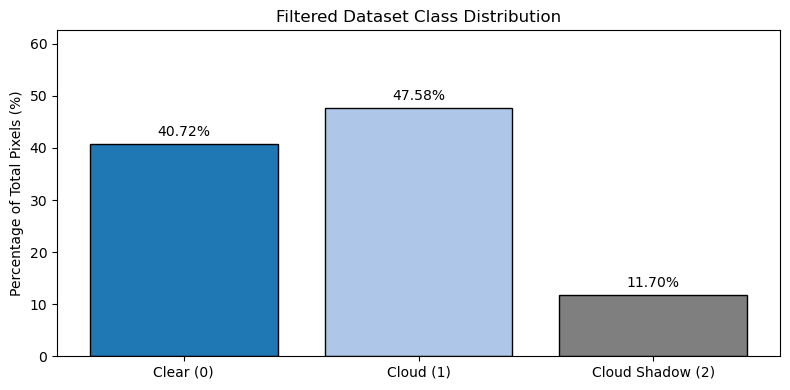

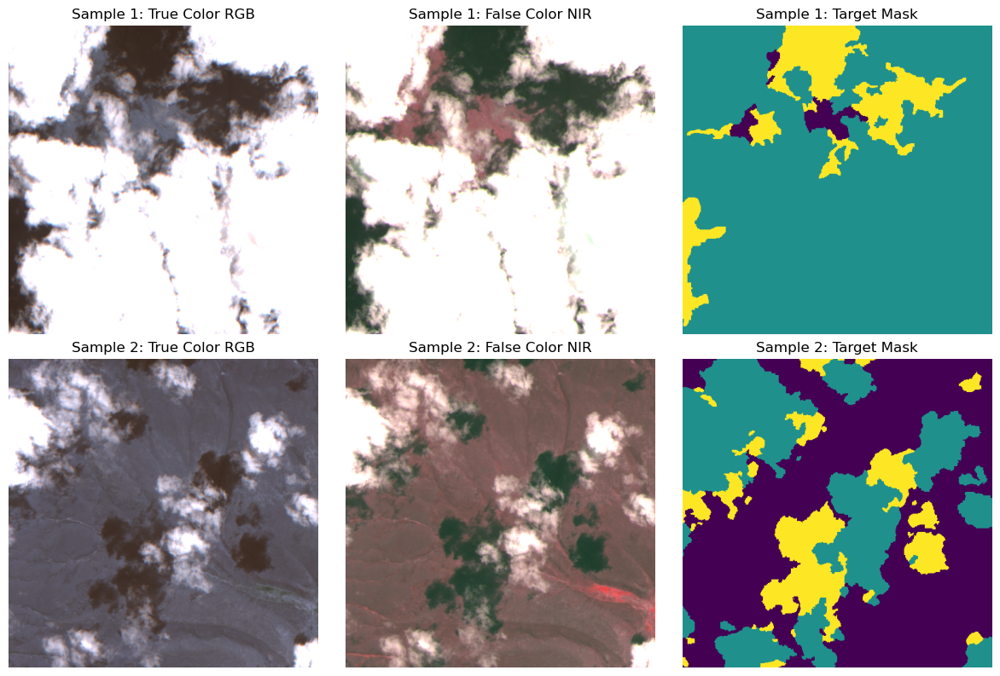

In [6]:
# EDA, FILTERING & WEIGHT CALCULATION

train_folder = "/Users/aidz/Desktop/PhilSA interview materials/data/train"
all_train_files = sorted(glob.glob(os.path.join(train_folder, "**", "*.tif"), recursive=True) + 
                         glob.glob(os.path.join(train_folder, "**", "*.tiff"), recursive=True))

class_counts = {0: 0, 1: 0, 2: 0} # 0=Clear, 1=Cloud, 2=Shadow
filtered_train_files = []
total_pixels = 0
MAX_DOMINANCE = 0.98 # Filter tiles where a single class takes up more than 98%

print("Running EDA and filtering uninformative tiles...")
for file_path in tqdm(all_train_files):
    with rasterio.open(file_path) as src:
        mask = src.read(5).astype(np.int64) # Read Band 5 mask
        
        # Apply your exact remapping logic for accurate counting
        remapped = np.zeros_like(mask)
        remapped[(mask == 1) | (mask == 2)] = 1
        remapped[mask == 3] = 2
        
        # Check class dominance
        unique_classes, counts = np.unique(remapped, return_counts=True)
        max_ratio = np.max(counts) / mask.size
        
        if max_ratio < MAX_DOMINANCE:
            filtered_train_files.append(file_path)
            
            # Tally pixels for weight calculation
            for cls, count in zip(unique_classes, counts):
                class_counts[cls] += count
            total_pixels += mask.size

print(f"\nFiltering Complete: Retained {len(filtered_train_files)} / {len(all_train_files)} images.")

# Compute Median Frequency Balancing Weights
frequencies = np.array([class_counts[0], class_counts[1], class_counts[2]]) / total_pixels
median_freq = np.median(frequencies)
computed_weights = median_freq / frequencies

# Convert to tensor for the loss function
class_weights_tensor = torch.tensor(computed_weights, dtype=torch.float32).to(device)
print(f"Computed PyTorch Class Weights: {class_weights_tensor.tolist()}")


# EDA OUTPUTS 

output_folder = "output_files"
os.makedirs(output_folder, exist_ok=True)

# Plot Class Distribution Bar Chart
class_names = ['Clear (0)', 'Cloud (1)', 'Cloud Shadow (2)']
pixel_values = [class_counts[0], class_counts[1], class_counts[2]]
percentages = [(p / total_pixels) * 100 for p in pixel_values]

plt.figure(figsize=(8, 4))
bars = plt.bar(class_names, percentages, color=['#1f77b4', '#aec7e8', '#7f7f7f'], edgecolor='black')
plt.ylabel('Percentage of Total Pixels (%)')
plt.title('Filtered Dataset Class Distribution')
plt.ylim(0, max(percentages) + 15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.2f}%", ha='center', va='bottom')

plt.tight_layout()

# Save plot as PDF before displaying
pdf_path = os.path.join(output_folder, "class_distribution.pdf")
plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"✅ Bar chart saved as PDF to '{pdf_path}'")

plt.show()
plt.close()

# For Rendering RGB, False-Color NIR, and Mask Sample Previews
num_samples = 2
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(min(num_samples, len(filtered_train_files))):
    with rasterio.open(filtered_train_files[i]) as src:
        data = src.read()
        img = np.clip(data[0:4, :, :].astype(np.float32) / 10000.0, 0.0, 1.0)
        mask = data[4, :, :].astype(np.int64)
        
        # Remap mask for display
        remapped = np.zeros_like(mask)
        remapped[(mask == 1) | (mask == 2)] = 1
        remapped[mask == 3] = 2
        
        # True Color RGB (B04, B03, B02) & False Color NIR (B08, B04, B03)
        rgb = np.clip(np.stack([img[2], img[1], img[0]], axis=-1) * 2.5, 0.0, 1.0)
        nir_fc = np.clip(np.stack([img[3], img[2], img[1]], axis=-1) * 2.5, 0.0, 1.0)
        
        axes[i, 0].imshow(rgb); axes[i, 0].set_title(f"Sample {i+1}: True Color RGB"); axes[i, 0].axis('off')
        axes[i, 1].imshow(nir_fc); axes[i, 1].set_title(f"Sample {i+1}: False Color NIR"); axes[i, 1].axis('off')
        axes[i, 2].imshow(remapped, vmin=0, vmax=2, cmap='viridis'); axes[i, 2].set_title(f"Sample {i+1}: Target Mask"); axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

Starting Retraining on mps...



Epoch [01/35] completed in 317s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000050 / 0.000300 | Train Loss: 0.9792 | Val Loss: 0.7938 | Val mIoU: 0.6649
  --> Saved new best checkpoint (mIoU: 0.6649)



Epoch [02/35] completed in 316s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000050 / 0.000300 | Train Loss: 0.7888 | Val Loss: 0.6382 | Val mIoU: 0.6868
  --> Saved new best checkpoint (mIoU: 0.6868)



Epoch [03/35] completed in 315s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000050 / 0.000300 | Train Loss: 0.7292 | Val Loss: 0.6237 | Val mIoU: 0.6957
  --> Saved new best checkpoint (mIoU: 0.6957)



Epoch [04/35] completed in 314s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000050 / 0.000300 | Train Loss: 0.6783 | Val Loss: 0.5805 | Val mIoU: 0.7445
  --> Saved new best checkpoint (mIoU: 0.7445)


...


Epoch [16/35] completed in 314s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000025 / 0.000150 | Train Loss: 0.4974 | Val Loss: 0.4626 | Val mIoU: 0.7663
  --> No improvement in mIoU for 3/7 epochs.



Epoch [17/35] completed in 316s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000013 / 0.000075 | Train Loss: 0.4948 | Val Loss: 0.4667 | Val mIoU: 0.7559
  --> No improvement in mIoU for 4/7 epochs.



Epoch [18/35] completed in 314s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000013 / 0.000075 | Train Loss: 0.4738 | Val Loss: 0.4706 | Val mIoU: 0.7573
  --> No improvement in mIoU for 5/7 epochs.



Epoch [19/35] completed in 318s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000013 / 0.000075 | Train Loss: 0.4646 | Val Loss: 0.4589 | Val mIoU: 0.7609
  --> No improvement in mIoU for 6/7 epochs.



Epoch [20/35] completed in 314s
Verified Files Processed -> Train: 3323 files | Val: 535 files
LR (Enc/Dec): 0.000013 / 0.000075 | Train Loss: 0.4589 | Val Loss: 0.4553 | Val mIoU: 0.7677
  --> No improvement in mIoU for 7/7 epochs.

🛑 Early stopping triggered at Epoch 20! Stopping training to avoid overfitting.

✅ Complete training history saved to 'output_files/training_history.csv'


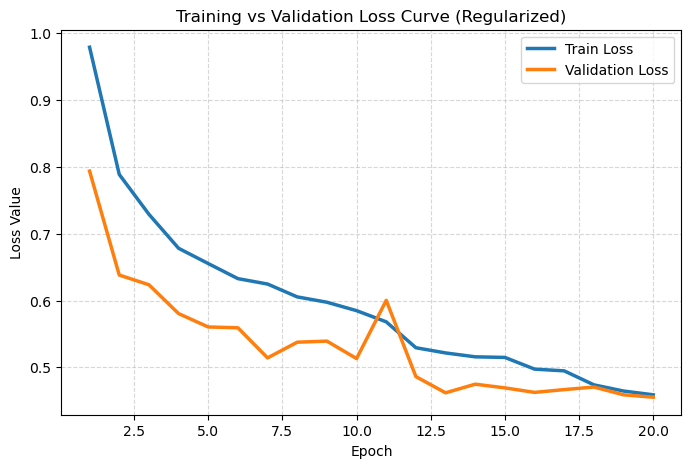

✅ Clean loss curve plot saved as PDF to 'output_files/loss_curve.pdf'


In [7]:
# we now train the model

# Re-seed RNG to start completely fresh
rand_seed(42)

# Hyperparameters
BATCH_SIZE = 8
EPOCHS = 35
EARLY_STOPPING_PATIENCE = 7  # Stops training if val mIoU doesn't improve for 7 epochs

# Datasets & Loaders
train_dataset = CloudData_Prep(file_paths=filtered_train_files, augment=True)
val_dataset = CloudData_Prep(folder_path="/Users/aidz/Desktop/PhilSA interview materials/data/val", augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Custom Loss Definition
class DiceCELoss(nn.Module):
    def __init__(self, ce_weight=None):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode='multiclass')
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
        
    def forward(self, preds, targets):
        return self.ce(preds, targets) + self.dice(preds, targets)

# Pretrained Model Setup
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=4,
    classes=3
).to(device)

criterion = DiceCELoss(ce_weight=class_weights_tensor)

# REGULARIZED OPTIMIZER: Separate learning rates for Encoder & Decoder
optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 5e-5},           # Group 0: Encoder LR
    {'params': model.decoder.parameters(), 'lr': 3e-4},           # Group 1: Decoder LR
    {'params': model.segmentation_head.parameters(), 'lr': 3e-4}  # Group 2: Head LR
], weight_decay=1e-3)

scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

# Output directory setup
output_folder = "output_files"
os.makedirs(output_folder, exist_ok=True)

history = []
best_miou = 0.0
patience_counter = 0

print(f"Starting Retraining on {device}...")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    end_time = time.time()
    epoch_duration = end_time - start_time

    # Calculate dataset sizes processed
    train_files_processed = len(train_loader.dataset)
    val_files_processed = len(val_loader.dataset)

    # Step learning rate scheduler and extract group LRs
    scheduler.step(val_metrics['macro_iou'])
    enc_lr = optimizer.param_groups[0]['lr']
    dec_lr = optimizer.param_groups[1]['lr']

    # Record history to dictionary
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_metrics['val_loss'],
        'val_macro_iou': val_metrics['macro_iou'],
        'val_macro_dice': val_metrics['macro_dice'],
        'val_macro_precision': val_metrics['macro_precision'],
        'val_macro_recall': val_metrics['macro_recall'],
        'encoder_lr': enc_lr,
        'decoder_lr': dec_lr,
        'duration_seconds': round(epoch_duration, 2)
    })

    # Print Detailed Per-Epoch Logs
    print(f"\nEpoch [{epoch:02d}/{EPOCHS:02d}] completed in {epoch_duration:.0f}s")
    print(f"Verified Files Processed -> Train: {train_files_processed} files | Val: {val_files_processed} files")
    print(f"LR (Enc/Dec): {enc_lr:.6f} / {dec_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['val_loss']:.4f} | Val mIoU: {val_metrics['macro_iou']:.4f}")

    # Checkpoint Check
    if val_metrics['macro_iou'] > best_miou:
        best_miou = val_metrics['macro_iou']
        torch.save(model.state_dict(), "best_cloud_model.pth")
        print(f"  --> Saved new best checkpoint (mIoU: {best_miou:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  --> No improvement in mIoU for {patience_counter}/{EARLY_STOPPING_PATIENCE} epochs.")

    # Early Stopping Trigger
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered at Epoch {epoch}! Stopping training to avoid overfitting.")
        break

# Save Training Metrics to CSV
df_history = pd.DataFrame(history)
history_csv_path = os.path.join(output_folder, "training_history.csv")
df_history.to_csv(history_csv_path, index=False)
print(f"\n✅ Complete training history saved to '{history_csv_path}'")

# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(df_history['epoch'], df_history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2.5)
plt.plot(df_history['epoch'], df_history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5)
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.title('Training vs Validation Loss Curve (Regularized)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

curve_pdf_path = os.path.join(output_folder, "loss_curve.pdf")
plt.savefig(curve_pdf_path, format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Clean loss curve plot saved as PDF to '{curve_pdf_path}'")

#### Output visualization

In [9]:
# creates the two-band GeoTIFF output for export

def export_twoband_geotiff(input_path, output_path, model, device):
    model.eval()
    with rasterio.open(input_path) as src:
        meta = src.meta.copy()
        data = src.read()
        
        # read multispectral channels
        img = data[0:4, :, :].astype(np.float32)
        img_norm = np.clip(img / 10000.0, 0.0, 1.0)
        
        tensor_img = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits = model(tensor_img)
            probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()  # Shape: (3, H, W)
            
        # Band 1: (0=Clear, 1=Cloud, 2=Cloud Shadow)
        band1_mask = np.argmax(probs, axis=0).astype(np.uint8)
        
        # Band 2: Classification Confidence (0-100)
        max_prob = np.max(probs, axis=0)
        band2_confidence = np.round(max_prob * 100.0).astype(np.uint8)
        
        # Update metadata for two-band 8-bit output
        meta.update({
            'count': 2,
            'dtype': 'uint8',
            'driver': 'GTiff'
        })
        
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(band1_mask, 1)
            dst.set_band_description(1, 'Cloud and Cloud Shadow Mask')
            
            dst.write(band2_confidence, 2)
            dst.set_band_description(2, 'Classification Confidence')
            
    return band1_mask, band2_confidence

Starting batch processing for 10 random images...

Processing image 1/10: 20190416T072621_20190416T074442_T37PHK.tif


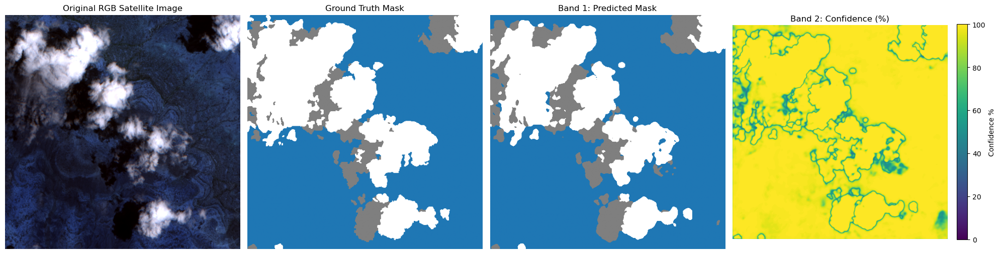

  ✅ Saved 'output_map_sample_0.tif' and 'storyboard_sample_0.png'
Processing image 2/10: 20190706T144739_20190706T145618_T19KEB.tif


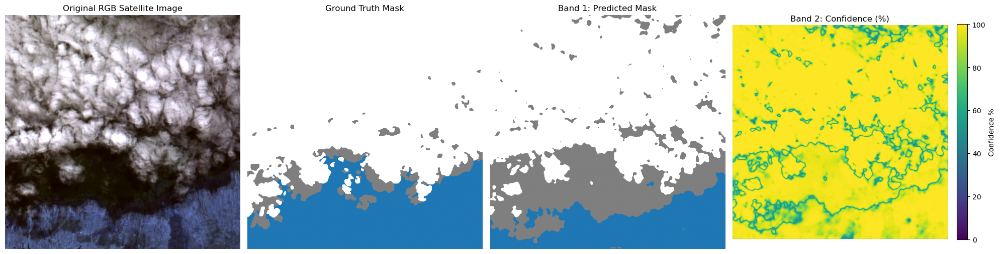

  ✅ Saved 'output_map_sample_1.tif' and 'storyboard_sample_1.png'
Processing image 3/10: 20200616T162839_20200616T164323_T15QXU.tif


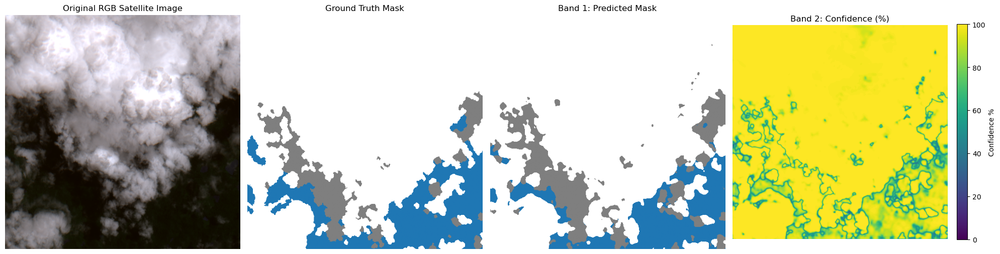

  ✅ Saved 'output_map_sample_2.tif' and 'storyboard_sample_2.png'
Processing image 4/10: 20190827T014659_20190827T014656_T53TPM.tif


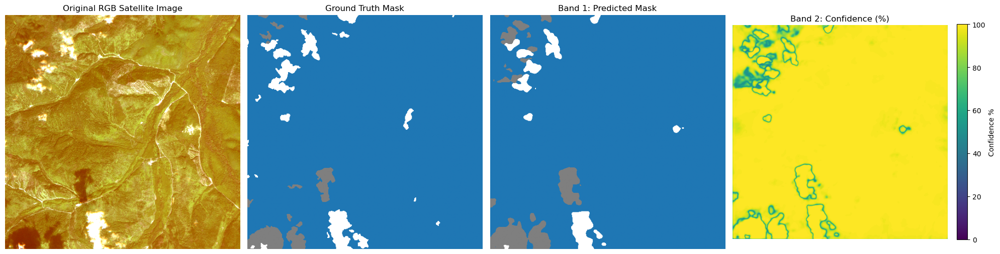

  ✅ Saved 'output_map_sample_3.tif' and 'storyboard_sample_3.png'
Processing image 5/10: 20190407T144739_20190407T145613_T19LDD.tif


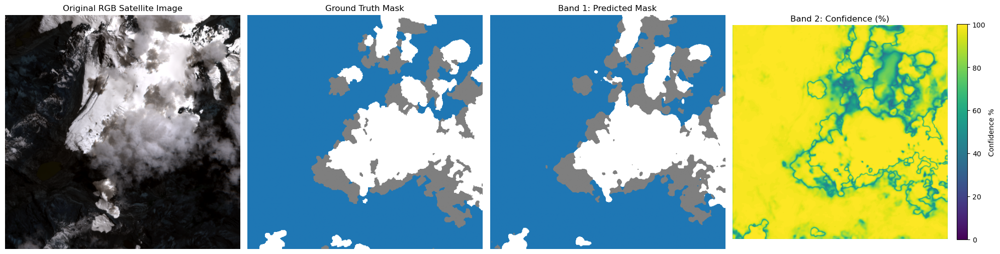

  ✅ Saved 'output_map_sample_4.tif' and 'storyboard_sample_4.png'
Processing image 6/10: 20190629T013719_20190629T014021_T52LGL.tif


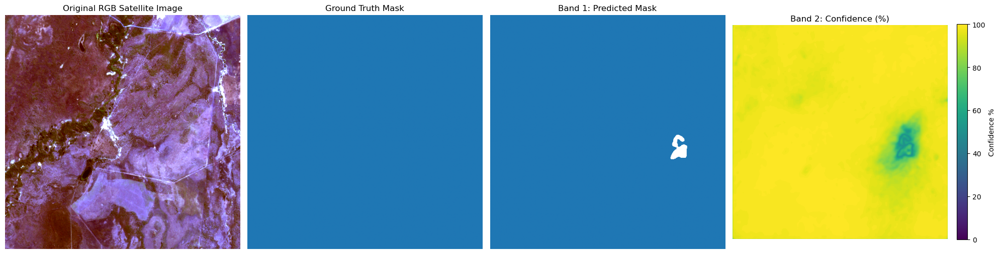

  ✅ Saved 'output_map_sample_5.tif' and 'storyboard_sample_5.png'
Processing image 7/10: 20191022T145731_20191022T150543_T19LBD.tif


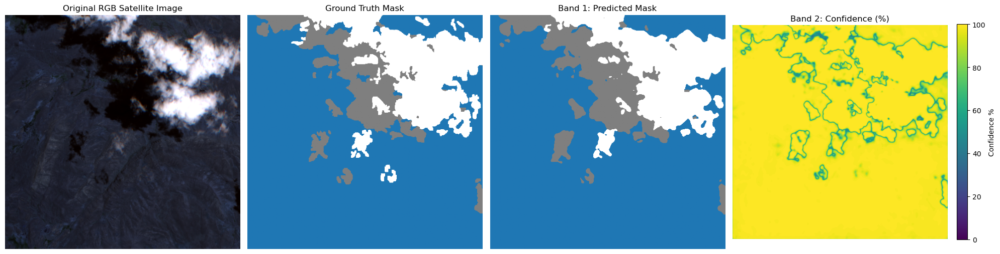

  ✅ Saved 'output_map_sample_6.tif' and 'storyboard_sample_6.png'
Processing image 8/10: 20200712T173911_20200712T174044_T14VPM.tif


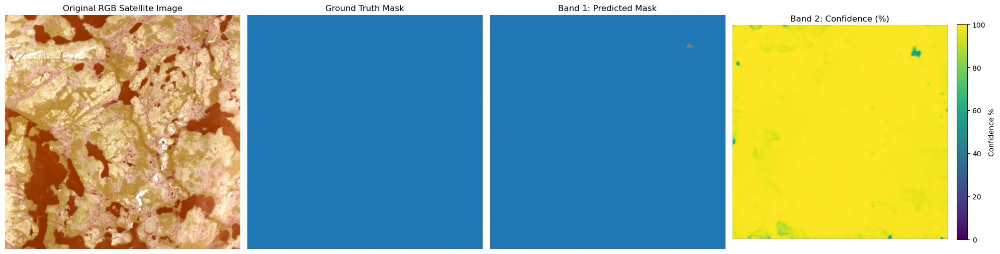

  ✅ Saved 'output_map_sample_7.tif' and 'storyboard_sample_7.png'
Processing image 9/10: 20190608T014659_20190608T014659_T56WMU.tif


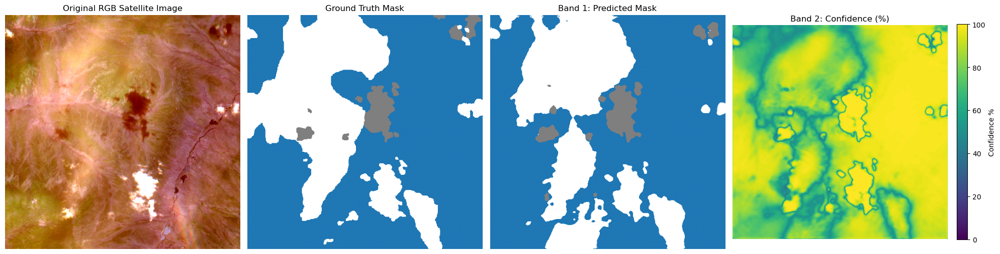

  ✅ Saved 'output_map_sample_8.tif' and 'storyboard_sample_8.png'
Processing image 10/10: 20191221T145721_20191221T145719_T19LBD.tif


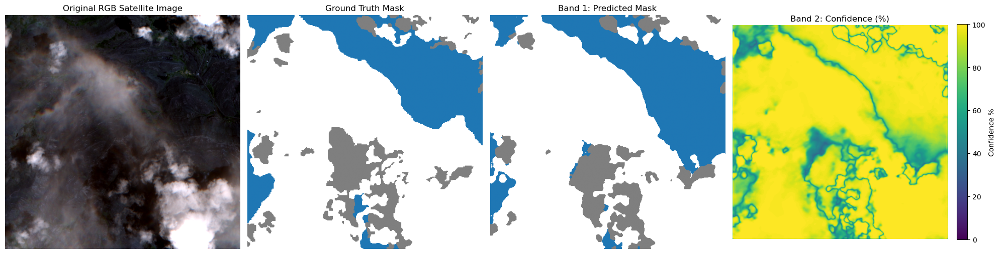

  ✅ Saved 'output_map_sample_9.tif' and 'storyboard_sample_9.png'

All 10 images successfully processed and saved.


In [14]:
def create_rgb(input_path):
    with rasterio.open(input_path) as src:
        data = src.read()
        # Band 3: Red (B04), Band 2: Green (B03), Band 1: Blue (B02)
        red = data[2, :, :].astype(np.float32)
        green = data[1, :, :].astype(np.float32)
        blue = data[0, :, :].astype(np.float32)
        
        rgb = np.stack([red, green, blue], axis=-1)
        
        # Percentile contrast stretch for true-color visualization
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb_stretched = np.clip((rgb - p2) / (p98 - p2 + 1e-7), 0, 1)
        return rgb_stretched

def visualize_sample(input_path, output_tif_path, output_png_path, model, device):
    mask_pred, conf_pred = export_twoband_geotiff(input_path, output_tif_path, model, device)
    rgb_img = create_rgb(input_path)
    
    with rasterio.open(input_path) as src:
        gt_mask = src.read(5).astype(np.int64)
        
    gt_remapped = np.zeros_like(gt_mask)
    gt_remapped[gt_mask == 0] = 0
    gt_remapped[(gt_mask == 1) | (gt_mask == 2)] = 1
    gt_remapped[gt_mask == 3] = 2
    
    cmap_mask = ListedColormap(['#1f77b4', '#ffffff', '#7f7f7f'])  # Blue=Clear, White=Cloud, Gray=Shadow
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title("Original RGB Satellite Image")
    axes[0].axis("off")
    
    axes[1].imshow(gt_remapped, cmap=cmap_mask, vmin=0, vmax=2)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")
    
    axes[2].imshow(mask_pred, cmap=cmap_mask, vmin=0, vmax=2)
    axes[2].set_title("Band 1: Predicted Mask")
    axes[2].axis("off")
    
    im_conf = axes[3].imshow(conf_pred, cmap="viridis", vmin=0, vmax=100)
    axes[3].set_title("Band 2: Confidence (%)")
    axes[3].axis("off")
    
    cbar = fig.colorbar(im_conf, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label("Confidence %")
    
    plt.tight_layout()
    
    # Saves the visual storyboard as a high-quality PNG before displaying it
    plt.savefig(output_png_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig) # Closes the image in the background to save computer memory

# Run visualization on a sample test patch
test_folder = "/Users/aidz/Desktop/PhilSA interview materials/data/test"

# Search for both .tif and .tiff recursively inside the test folder
test_files = sorted(glob.glob(os.path.join(test_folder, "**", "*.tif"), recursive=True) + 
                    glob.glob(os.path.join(test_folder, "**", "*.tiff"), recursive=True))

if len(test_files) > 0:
    output_folder = "output_files"
    os.makedirs(output_folder, exist_ok=True)
    
    num_images_to_test = min(10, len(test_files))
    print(f"Starting batch processing for {num_images_to_test} random images...\n")
    
    # Grab 10 random files from your full list
    random_selection = random.sample(test_files, num_images_to_test)
    
    # Loop through your new random selection
    for i, current_file in enumerate(random_selection):
        
        # Print the actual file name so you know which random one was picked
        file_basename = os.path.basename(current_file)
        print(f"Processing image {i + 1}/{num_images_to_test}: {file_basename}")
        
        tif_name = f"output_map_sample_{i}.tif"
        png_name = f"storyboard_sample_{i}.png"
        
        full_tif_path = os.path.join(output_folder, tif_name)
        full_png_path = os.path.join(output_folder, png_name)
        
        visualize_sample(current_file, full_tif_path, full_png_path, model, device)
        
        print(f"  ✅ Saved '{tif_name}' and '{png_name}'")
        
    print(f"\nAll {num_images_to_test} images successfully processed and saved.")
else:
    print("❌ Could not find any test images. Please check your test folder.")

## Performance Eval

In [12]:
test_dataset = CloudData_Prep("data/test")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.load_state_dict(torch.load("best_cloud_model.pth"))
test_metrics = validate_epoch(model, test_loader, criterion, device)

# Build summary results DataFrame
df_results = pd.DataFrame({
    'Class': ['Clear (0)', 'Cloud (1)', 'Cloud Shadow (2)', 'Macro Average'],
    'IoU': test_metrics['iou'] + [test_metrics['macro_iou']],
    'Dice / F1': test_metrics['dice'] + [test_metrics['macro_dice']],
    'Precision': test_metrics['precision'] + [test_metrics['macro_precision']],
    'Recall': test_metrics['recall'] + [test_metrics['macro_recall']]
})

print("=== Assessment Evaluation Summary ===")
print(df_results.to_string(index=False))

# save to same folder 
output_folder = "output_files"
os.makedirs(output_folder, exist_ok=True)

csv_path = os.path.join(output_folder, "model_performance_metrics.csv")

metrics_df = pd.DataFrame([test_metrics])

# Save to CSV 2 formats
metrics_df.to_csv(csv_path, index=False)
df_results.to_csv("/Users/aidz/Desktop/PhilSA interview materials/output_files/trial.csv")

print(f"✅ Performance metrics successfully saved to '{csv_path}'!")

=== Assessment Evaluation Summary ===
           Class      IoU  Dice / F1  Precision   Recall
       Clear (0) 0.867897   0.929277   0.922046 0.936623
       Cloud (1) 0.810666   0.895434   0.934409 0.859580
Cloud Shadow (2) 0.612633   0.759792   0.689530 0.845998
   Macro Average 0.763732   0.861501   0.848662 0.880734
✅ Performance metrics successfully saved to 'output_files/model_performance_metrics.csv'!
